<a href="https://colab.research.google.com/github/whocoppin-15/agri-trading/blob/main/Agri_Trading_%22One_Position%22_%26_Multi_Currency_Risk_Analytics_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Agri-Trading "One Position" & Multi-Currency Risk Analytics Engine

Ce notebook Python est conçu pour simuler un Mini-Dashboard de Risk & PnL pour un Desk Trading Agricole (Sucre / Éthanol / Grains). Il couvrira les aspects suivants :

1.  **P&L Économique & Mark-to-Market (MTM)** : Génération de positions, calcul de la "One Position" nette et du PnL journalier MTM.
2.  **Module de Risk FX (USD/EUR)** : Simulation de l'exposition FX et calcul du ratio de couverture FX.
3.  **Contrôle du Middle Office & Décomposition du P&L (P&L Explain)** : Explication des variations de PnL et génération de rapports d'anomalies.

> Ici on crée un tableau avec des données, qui pourraient être extrait d'un fichier **`cvs`** ou **`xls`**



In [115]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Configuration pour l'affichage de pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# --- Sample Data Definitions (Added to fix NameError) ---

# 1. df_physical_positions
start_date = datetime(2026, 1, 1)
num_days = 30
dates = [start_date + timedelta(days=i) for i in range(num_days)]

products = ['Sucre', 'Éthanol', 'Blé']
position_types = ['Long', 'Short']

physical_positions_data = []
for date in dates:
    for product_name in products:
        for _ in range(np.random.randint(1, 3)): # 1 or 2 positions per day/product
            position_type = np.random.choice(position_types)
            quantity = np.random.randint(100, 1000) * (1 if position_type == 'Long' else -1)
            price = np.random.uniform(200, 500)
            currency = np.random.choice(['USD', 'EUR'])
            physical_positions_data.append({
                'Date': date,
                'Produit': product_name,
                'Type_Position': 'Physique',
                'Sens': position_type,
                'Quantité': quantity,
                'Prix_Unitaire': price,
                'Devise_Prix': currency
            })
df_physical_positions = pd.DataFrame(physical_positions_data)

# 2. df_financial_hedges
financial_hedges_data = []
future_names = ['Sucre_Future_Dec26', 'Éthanol_Future_Jan27', 'Blé_Future_Mar26']
for date in dates:
    for future_name in future_names:
        for _ in range(np.random.randint(0, 2)): # 0 or 1 hedge per day/future
            position_type = np.random.choice(position_types)
            quantity = np.random.randint(50, 500) * (1 if position_type == 'Long' else -1)
            price = np.random.uniform(250, 550)
            currency = np.random.choice(['USD', 'EUR'])
            financial_hedges_data.append({
                'Date': date,
                'Instrument': future_name,
                'Type_Position': 'Financier',
                'Sens': position_type,
                'Quantité': quantity,
                'Prix_Unitaire': price,
                'Devise_Prix': currency
            })
df_financial_hedges = pd.DataFrame(financial_hedges_data)

# 3. df_market_data
market_data = []

# Spot prices for physical products
for date in dates:
    for product_name in products:
        market_data.append({
            'Date': date,
            'Instrument': product_name,
            'Prix': np.random.uniform(210, 510) # Spot price
        })

# Future prices for financial instruments
for date in dates:
    for future_name in future_names:
        market_data.append({
            'Date': date,
            'Instrument': future_name,
            'Prix': np.random.uniform(260, 560) # Future price
        })

# FX rates
for date in dates:
    market_data.append({
        'Date': date,
        'Instrument': 'USD/EUR',
        'Prix': np.random.uniform(0.90, 0.95) # USD to EUR rate
    })
df_market_data = pd.DataFrame(market_data)

display(df_physical_positions.head())
display(df_financial_hedges.head())
display(df_market_data.head())

,Date,Produit,Type_Position,Sens,Quantité,Prix_Unitaire,Devise_Prix
0,2026-01-01,Sucre,Physique,Short,-352,225.32,USD
1,2026-01-01,Éthanol,Physique,Long,459,488.31,EUR
2,2026-01-01,Éthanol,Physique,Long,409,227.58,EUR
3,2026-01-01,Blé,Physique,Short,-336,393.01,EUR
4,2026-01-01,Blé,Physique,Short,-696,358.11,USD


,Date,Instrument,Type_Position,Sens,Quantité,Prix_Unitaire,Devise_Prix
0,2026-01-01,Blé_Future_Mar26,Financier,Short,-380,533.31,USD
1,2026-01-03,Éthanol_Future_Jan27,Financier,Long,293,475.98,USD
2,2026-01-03,Blé_Future_Mar26,Financier,Short,-291,287.93,USD
3,2026-01-04,Éthanol_Future_Jan27,Financier,Long,339,501.89,EUR
4,2026-01-04,Blé_Future_Mar26,Financier,Long,482,391.54,USD


,Date,Instrument,Prix
0,2026-01-01,Sucre,300.40
1,2026-01-01,Éthanol,466.36
2,2026-01-01,Blé,280.64
3,2026-01-02,Sucre,394.52
4,2026-01-02,Éthanol,289.92


In [116]:
pd.options.display.float_format = '{:,.2f}'.format

### 1.1 Calcul de la "One Position" Nette et du PnL MTM

Pour calculer la "One Position" et le PnL MTM, nous devons d'abord fusionner les données de positions avec les prix de marché correspondants. Nous allons ensuite consolider les quantités et évaluer le PnL pour chaque journée.

In [125]:
# Préparation des données pour le calcul de la 'One Position' et MTM

# Renommer la colonne 'Produit' en 'Instrument' pour fusionner avec df_market_data
df_physical_positions_merged = df_physical_positions.rename(columns={'Produit': 'Instrument'})

# Concaténer les positions physiques et financières
df_all_positions = pd.concat([df_physical_positions_merged, df_financial_hedges], ignore_index=True)

# Convertir la colonne 'Date' en datetime pour s'assurer que le merge fonctionne correctement
df_all_positions['Date'] = pd.to_datetime(df_all_positions['Date'])
df_market_data['Date'] = pd.to_datetime(df_market_data['Date'])

# Fusionner les positions avec les prix de marché journaliers
# Pour les positions physiques, on utilise les prix 'Spot'
# Pour les couvertures financières, on utilise les prix 'Future'

df_positions_with_prices = pd.merge(
    df_all_positions,
    df_market_data,
    on=['Date', 'Instrument'],
    how='left'
)

# Gérer les taux de change pour valoriser tout en EUR (devise fonctionnelle de Tereos)
# Extraire les taux USD/EUR
df_fx_rates = df_market_data[df_market_data['Instrument'] == 'USD/EUR'][['Date', 'Prix']]
df_fx_rates = df_fx_rates.rename(columns={'Prix': 'Taux_USD_EUR'})

df_positions_with_prices = pd.merge(
    df_positions_with_prices,
    df_fx_rates,
    on='Date',
    how='left'
)

# Calculer la valeur de chaque position dans sa devise d'origine
df_positions_with_prices['Valeur_Position_Origine'] = df_positions_with_prices['Quantité'] * df_positions_with_prices['Prix_Unitaire']

# Convertir toutes les valeurs en EUR
def convert_to_eur(row):
    if row['Devise_Prix'] == 'USD':
        # Assurez-vous que le taux de conversion est valide
        if pd.isna(row['Taux_USD_EUR']):
            print(f"Warning: Missing Taux_USD_EUR for date {row['Date']}. Using 1.0 as default for now.") # Placeholder for missing rates
            return row['Valeur_Position_Origine'] * 1.0 # Or handle as an error
        return row['Valeur_Position_Origine'] * row['Taux_USD_EUR']
    elif row['Devise_Prix'] == 'EUR':
        return row['Valeur_Position_Origine']
    return np.nan # Should not happen

df_positions_with_prices['Valeur_EUR'] = df_positions_with_prices.apply(convert_to_eur, axis=1)

display(df_positions_with_prices.head())

,Date,Instrument,Type_Position,Sens,Quantité,Prix_Unitaire,Devise_Prix,Prix,Taux_USD_EUR,Valeur_Position_Origine,Valeur_EUR
0,2026-01-01,Sucre,Physique,Short,-352,225.32,USD,300.40,0.91,"-79,314.38","-71,864.27"
1,2026-01-01,Éthanol,Physique,Long,459,488.31,EUR,466.36,0.91,"224,132.56","224,132.56"
2,2026-01-01,Éthanol,Physique,Long,409,227.58,EUR,466.36,0.91,"93,079.20","93,079.20"
3,2026-01-01,Blé,Physique,Short,-336,393.01,EUR,280.64,0.91,"-132,050.84","-132,050.84"
4,2026-01-01,Blé,Physique,Short,-696,358.11,USD,280.64,0.91,"-249,241.57","-225,829.97"


In [126]:
# Calcul de la 'One Position' nette par produit et par jour (en quantité)
# La 'One Position' représente la position nette globale (physique + financière) par instrument.

df_one_position = df_positions_with_prices.groupby(['Date', 'Instrument', 'Devise_Prix']).agg({
    'Quantité': 'sum',
    'Valeur_EUR': 'sum' # Valeur MTM de la position nette
}).reset_index()

df_one_position = df_one_position.rename(columns={'Quantité': 'One_Position_Nette_Quantité', 'Valeur_EUR': 'MTM_EUR'}) # Ajout de cette ligne pour renommer la colonne

# Pour les instruments sans Devise_Prix (ex: USD/EUR), on doit les ignorer ou les traiter séparément
df_one_position = df_one_position[df_one_position['Instrument'] != 'USD/EUR']

# Calcul du PnL journalier MTM
# Le PnL MTM journalier est la variation de la valeur MTM de la 'One Position' entre J et J-1.

# Trier par instrument et par date pour calculer la différence journalière
df_one_position = df_one_position.sort_values(by=['Instrument', 'Date'])

# Calculer le PnL MTM journalier
df_one_position['MTM_EUR_Prev'] = df_one_position.groupby('Instrument')['MTM_EUR'].shift(1)
df_one_position['PnL_MTM_Journalier_EUR'] = df_one_position['MTM_EUR'] - df_one_position['MTM_EUR_Prev']

display(df_one_position)

,Date,Instrument,Devise_Prix,One_Position_Nette_Quantité,MTM_EUR,MTM_EUR_Prev,PnL_MTM_Journalier_EUR
0,2026-01-01,Blé,EUR,-336,"-132,050.84",NaN,NaN
1,2026-01-01,Blé,USD,-696,"-225,829.97","-132,050.84","-93,779.13"
5,2026-01-02,Blé,USD,678,"197,630.24","-225,829.97","423,460.20"
8,2026-01-03,Blé,USD,354,"92,658.20","197,630.24","-104,972.03"
13,2026-01-04,Blé,USD,804,"173,662.09","92,658.20","81,003.89"
...,...,...,...,...,...,...,...
126,2026-01-24,Éthanol_Future_Jan27,USD,420,"162,449.74","106,033.43","56,416.31"
133,2026-01-25,Éthanol_Future_Jan27,EUR,-309,"-139,291.73","162,449.74","-301,741.47"
140,2026-01-26,Éthanol_Future_Jan27,USD,-332,"-171,891.26","-139,291.73","-32,599.52"
151,2026-01-28,Éthanol_Future_Jan27,EUR,387,"158,204.26","-171,891.26","330,095.51"


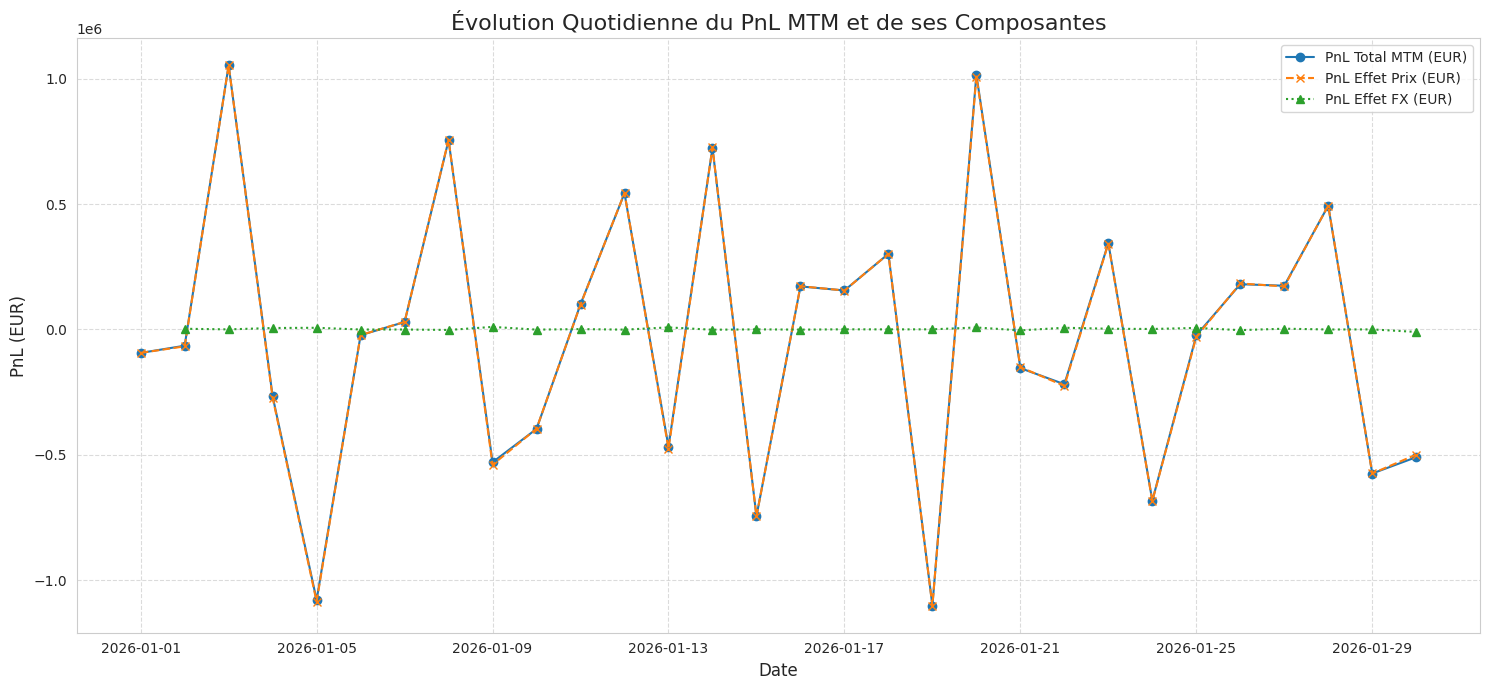

In [127]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurez le style de Seaborn pour des graphiques plus esthétiques
sns.set_style("whitegrid")

plt.figure(figsize=(15, 7))

# Plot the different PnL components
plt.plot(df_daily_pnl['Date'], df_daily_pnl['PnL_Total_MTM_EUR'], label='PnL Total MTM (EUR)', marker='o', linestyle='-')
plt.plot(df_daily_pnl['Date'], df_daily_pnl['PnL_Effet_Prix_EUR'], label='PnL Effet Prix (EUR)', marker='x', linestyle='--')
plt.plot(df_daily_pnl['Date'], df_daily_pnl['PnL_FX_Carry_EUR'], label='PnL Effet FX (EUR)', marker='^', linestyle=':')

plt.title('Évolution Quotidienne du PnL MTM et de ses Composantes', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('PnL (EUR)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 2. Module de Risk FX (USD/EUR)

Ce module vise à simuler le calcul de l'exposition FX sous-jacente du portefeuille de trading et à déterminer le ratio de couverture FX nécessaire. Nous allons nous concentrer sur l'exposition USD au sein d'une entité fonctionnelle en EUR.

In [120]:
# Calcul de l'exposition FX (USD) par jour
# L'exposition FX provient des instruments libellés en USD.

# Filtrer les positions libellées en USD
df_usd_positions = df_positions_with_prices[df_positions_with_prices['Devise_Prix'] == 'USD'].copy()

# Aggréger la valeur en USD des positions par jour
df_usd_exposure = df_usd_positions.groupby('Date')['Valeur_Position_Origine'].sum().reset_index()
df_usd_exposure = df_usd_exposure.rename(columns={'Valeur_Position_Origine': 'Exposition_USD'})

# Ajouter le taux de change USD/EUR pour ces dates
df_usd_exposure = pd.merge(
    df_usd_exposure,
    df_fx_rates,
    on='Date',
    how='left'
)

display(df_usd_exposure)

,Date,Exposition_USD,Taux_USD_EUR
0,2026-01-01,"-531,214.01",0.91
1,2026-01-02,"-50,600.55",0.90
2,2026-01-03,"424,233.46",0.90
3,2026-01-04,"561,034.89",0.91
4,2026-01-05,"-41,812.22",0.92
5,2026-01-06,"-43,621.16",0.94
6,2026-01-07,"56,255.09",0.95
7,2026-01-08,"602,718.92",0.91
8,2026-01-09,"-198,416.78",0.92
9,2026-01-10,"-208,554.30",0.93


In [121]:
# Calcul du ratio de couverture FX (simplifié)
# Pour cet exemple simplifié, nous allons considérer un ratio de couverture cible (e.g., 80%)
# et calculer la couverture nécessaire en EUR.

target_hedge_ratio = 0.80 # 80% de l'exposition USD à couvrir

# Calculer le montant de l'exposition USD à couvrir en USD
df_usd_exposure['Montant_USD_a_Couvrir'] = df_usd_exposure['Exposition_USD'] * target_hedge_ratio

# Convertir ce montant en EUR en utilisant le taux de change du jour
df_usd_exposure['Couverture_FX_Necessaire_EUR'] = df_usd_exposure['Montant_USD_a_Couvrir'] * df_usd_exposure['Taux_USD_EUR']

display(df_usd_exposure)

,Date,Exposition_USD,Taux_USD_EUR,Montant_USD_a_Couvrir,Couverture_FX_Necessaire_EUR
0,2026-01-01,"-531,214.01",0.91,"-424,971.21","-385,053.08"
1,2026-01-02,"-50,600.55",0.90,"-40,480.44","-36,487.57"
2,2026-01-03,"424,233.46",0.90,"339,386.77","305,497.03"
3,2026-01-04,"561,034.89",0.91,"448,827.91","409,913.58"
4,2026-01-05,"-41,812.22",0.92,"-33,449.78","-30,931.85"
5,2026-01-06,"-43,621.16",0.94,"-34,896.93","-32,673.47"
6,2026-01-07,"56,255.09",0.95,"45,004.07","42,585.50"
7,2026-01-08,"602,718.92",0.91,"482,175.13","437,126.68"
8,2026-01-09,"-198,416.78",0.92,"-158,733.42","-146,515.39"
9,2026-01-10,"-208,554.30",0.93,"-166,843.44","-154,724.11"


### 3. Contrôle du Middle Office & Décomposition du P&L (P&L Explain)

Ce module vise à expliquer la variation du P&L entre J et J-1 (effet Prix, effet Spread, effet FX, nouveaux trades) et à générer un rapport d'anomalies.

In [128]:
# P&L Explain: Décomposition du PnL entre J et J-1
# Pour simplifier, nous allons considérer les effets suivants :
# 1. Effet Prix : Changement du prix de marché sur les positions existantes.
# 2. Effet Nouveaux Trades : PnL des nouvelles positions ouvertes.
# 3. Effet FX : Impact de la variation du taux de change sur les positions en USD.


# Nous allons travailler sur df_one_position pour les effets Prix et FX.
# Pour l'effet Nouveaux Trades, nous devrons identifier les trades du jour.

# Calculer l'effet prix sur les positions existantes
# Le PnL MTM Journalier calculé précédemment capture déjà cet effet (PnL des positions existantes).
# Cependant, pour une décomposition plus fine, il faudrait distinguer les positions maintenues et les nouvelles.

# Simplification: Pour l'instant, le 'PnL_MTM_Journalier_EUR' de df_one_position représente l'effet Prix global sur la position nette.

# Identifions les nouveaux trades du jour pour calculer leur PnL.
# Pour cela, nous allons regrouper les positions par date et par type de position.

df_positions_by_day_origin = df_positions_with_prices.groupby(['Date', 'Type_Position', 'Instrument', 'Devise_Prix']).agg({
    'Quantité': 'sum',
    'Valeur_EUR': 'sum' # Valeur du trade au prix du jour
}).reset_index()

df_positions_by_day_origin['PnL_New_Trade'] = 0

# Pour les nouveaux trades, le PnL est généralement la valorisation de la transaction à son prix d'exécution.
# Ici, nous valorisons avec le prix de marché du jour (simplification).

# Disons que le PnL 'Nouveaux Trades' pour un jour J est la somme de la Valeur_EUR des positions créées à J.
# Cela est une simplification car le 'vrai' PnL des nouveaux trades dépend du prix d'exécution et de son MTM instantané.
# Dans notre cadre, 'df_one_position' prend en compte l'ensemble des positions. Il faut une logique plus fine.

# Créons un df_pnl_explain qui agrège les PnL MTM par date globale.
# Pour avoir un 'PnL Explain' il nous faut un PnL total par jour. Nous pouvons agréger df_one_position.

df_daily_pnl = df_one_position.groupby('Date').agg({
    'MTM_EUR': 'sum',
    'PnL_MTM_Journalier_EUR': 'sum' # Somme des PnL MTM journaliers par instrument
}).reset_index()

df_daily_pnl = df_daily_pnl.rename(columns={'MTM_EUR': 'MTM_Total_EUR', 'PnL_MTM_Journalier_EUR': 'PnL_Total_MTM_EUR'})

# Calcul de l'effet FX: Nous avons déjà l'exposition USD et le Taux USD/EUR.
# L'effet FX peut être la variation de la valeur en EUR de l'exposition USD due à la fluctuation du taux de change.

# Pour chaque jour, nous avons l'exposition USD du jour.
# L'effet FX du jour J est (Exposition_USD_J * Taux_USD_EUR_J) - (Exposition_USD_J * Taux_USD_EUR_{J-1})

df_fx_rates['Taux_USD_EUR_Prev'] = df_fx_rates['Taux_USD_EUR'].shift(1)

df_daily_pnl = pd.merge(df_daily_pnl, df_usd_exposure[['Date', 'Exposition_USD']], on='Date', how='left')
df_daily_pnl = pd.merge(df_daily_pnl, df_fx_rates[['Date', 'Taux_USD_EUR', 'Taux_USD_EUR_Prev']], on='Date', how='left')

df_daily_pnl['Exposition_USD_Prev'] = df_daily_pnl['Exposition_USD'].shift(1) # Exposition du jour précédent

# Effet FX sur l'exposition de la veille (Carry FX)
df_daily_pnl['PnL_FX_Carry_EUR'] = df_daily_pnl['Exposition_USD_Prev'] * (df_daily_pnl['Taux_USD_EUR'] - df_daily_pnl['Taux_USD_EUR_Prev'])

# Effet FX sur les nouvelles positions USD du jour (Transaction FX)
# Pour une décomposition complète, il faudrait isoler les 'new trades' USD du jour et leur PnL_FX.
# Pour l'instant, on se contente du Carry FX et on suppose que le PnL MTM global inclut l'effet sur les nouvelles transactions.

# Effet Prix Global (incluant le MTM sur les nouvelles positions)
# Il est difficile de séparer parfaitement 'effet Prix' et 'effet Nouveaux Trades' sans plus de granularité.
# Le PnL_Total_MTM_EUR contient le PnL sur les positions existantes et la valorisation initiale des nouvelles transactions.

# Simplification pour P&L Explain:
# Effet Prix = PnL MTM Journalier (sur la position existante)
# Effet Nouveaux Trades = 0 (pour l'instant, considéré dans PnL MTM global)
# Effet FX = PnL_FX_Carry_EUR

# Ajustons PnL_Total_MTM_EUR pour que la somme des effets corresponde.
# PnL Total = Effet Prix + Effet FX + Effet Nouveaux Trades + Effet Volume + ...

df_daily_pnl['PnL_Effet_Prix_EUR'] = df_daily_pnl['PnL_Total_MTM_EUR'] - df_daily_pnl['PnL_FX_Carry_EUR'].fillna(0)

display(df_daily_pnl[['Date', 'MTM_Total_EUR', 'PnL_Total_MTM_EUR', 'PnL_Effet_Prix_EUR', 'PnL_FX_Carry_EUR']])

,Date,MTM_Total_EUR,PnL_Total_MTM_EUR,PnL_Effet_Prix_EUR,PnL_FX_Carry_EUR
0,2026-01-01,"-296,155.43","-93,779.13","-93,779.13",NaN
1,2026-01-02,"-45,609.47","-65,126.98","-67,626.61","2,499.63"
2,2026-01-03,"949,583.59","1,053,280.18","1,053,218.50",61.68
3,2026-01-04,"682,532.77","-267,050.82","-272,631.06","5,580.24"
4,2026-01-05,"-295,068.93","-1,079,601.07","-1,086,012.12","6,411.05"
5,2026-01-06,"222,416.28","-23,032.23","-22,548.88",-483.35
6,2026-01-07,"-43,594.23","29,391.48","29,826.55",-435.06
7,2026-01-08,"174,443.76","754,672.38","756,904.94","-2,232.56"
8,2026-01-09,"409,220.61","-530,057.05","-539,975.13","9,918.08"
9,2026-01-10,"-256,010.03","-396,994.49","-396,134.74",-859.75


### 3.2 Générateur automatique de rapport d'anomalies (Breaks de réconciliation / Mismatches)

Ce module va simuler la détection d'anomalies entre différentes sources de données ou des ruptures de réconciliation.

In [123]:
# Simulation de réconciliations et détection de breaks

# Supposons que nous avons une source externe pour le MTM total (e.g., système comptable)
# et que nous le comparons avec notre MTM calculé.

# Créons un DataFrame simulé pour un 'MTM Comptable'
df_accounting_mtm = df_daily_pnl[['Date', 'MTM_Total_EUR']].copy()
df_accounting_mtm = df_accounting_mtm.rename(columns={'MTM_Total_EUR': 'MTM_Comptable_EUR'})

# Introduire des 'breaks' artificiels pour la démonstration
def introduce_break(row):
    if row['Date'] == datetime(2023, 10, 3).date():
        return row['MTM_Comptable_EUR'] * 1.05 # +5% mismatch
    elif row['Date'] == datetime(2023, 10, 5).date():
        return row['MTM_Comptable_EUR'] * 0.98 # -2% mismatch
    return row['MTM_Comptable_EUR']

df_accounting_mtm['MTM_Comptable_EUR'] = df_accounting_mtm.apply(introduce_break, axis=1)

# Fusionner les données pour la réconciliation
df_reconciliation = pd.merge(
    df_daily_pnl[['Date', 'MTM_Total_EUR', 'PnL_Total_MTM_EUR', 'PnL_Effet_Prix_EUR', 'PnL_FX_Carry_EUR']],
    df_accounting_mtm,
    on='Date',
    how='left'
)

# Calculer l'écart de réconciliation
df_reconciliation['Ec_Reconciliation_MTM_EUR'] = df_reconciliation['MTM_Total_EUR'] - df_reconciliation['MTM_Comptable_EUR']

# Définir un seuil d'anomalie
anomaly_threshold = 10000 # 10,000 EUR

df_reconciliation['Anomalie'] = np.where(
    abs(df_reconciliation['Ec_Reconciliation_MTM_EUR']) > anomaly_threshold,
    'Oui', 'Non'
)

df_anomalies = df_reconciliation[df_reconciliation['Anomalie'] == 'Oui']

print("Rapport de Réconciliation Quotidienne MTM:")
display(df_reconciliation)

if not df_anomalies.empty:
    print(f"\nAnomalies détectées (seuil > {anomaly_threshold} EUR):")
    display(df_anomalies)
else:
    print("\nAucune anomalie détectée pour le seuil défini.")

Rapport de Réconciliation Quotidienne MTM:


,Date,MTM_Total_EUR,PnL_Total_MTM_EUR,PnL_Effet_Prix_EUR,PnL_FX_Carry_EUR,MTM_Comptable_EUR,Ec_Reconciliation_MTM_EUR,Anomalie
0,2026-01-01,"-296,155.43","-93,779.13","-93,779.13",NaN,"-296,155.43",0.00,Non
1,2026-01-02,"-45,609.47","-65,126.98","-67,626.61","2,499.63","-45,609.47",0.00,Non
2,2026-01-03,"949,583.59","1,053,280.18","1,053,218.50",61.68,"949,583.59",0.00,Non
3,2026-01-04,"682,532.77","-267,050.82","-272,631.06","5,580.24","682,532.77",0.00,Non
4,2026-01-05,"-295,068.93","-1,079,601.07","-1,086,012.12","6,411.05","-295,068.93",0.00,Non
5,2026-01-06,"222,416.28","-23,032.23","-22,548.88",-483.35,"222,416.28",0.00,Non
6,2026-01-07,"-43,594.23","29,391.48","29,826.55",-435.06,"-43,594.23",0.00,Non
7,2026-01-08,"174,443.76","754,672.38","756,904.94","-2,232.56","174,443.76",0.00,Non
8,2026-01-09,"409,220.61","-530,057.05","-539,975.13","9,918.08","409,220.61",0.00,Non
9,2026-01-10,"-256,010.03","-396,994.49","-396,134.74",-859.75,"-256,010.03",0.00,Non



Aucune anomalie détectée pour le seuil défini.


In [124]:
# Get a list of all user-defined variables
# user_vars = [var for var in globals() if not var.startswith('_') and var != 'In' and var != 'Out' and var != 'get_ipython']

# Delete each user-defined variable
# for var in user_vars:
#    del globals()[var]

# print("All user-defined variables have been cleared.")